<font color = "lime">

# EDA on 2020 Data
Source: Census of Population 2020

Link: https://www.singstat.gov.sg/find-data/search-by-theme/population/mode-of-transport/publications-and-methodology

</font>

---

### Import Required Libraries

In [1]:
# basic requirements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# for scaling (prepare data for modelling)
from sklearn.preprocessing import StandardScaler

# for modelling
from sklearn.decomposition import PCA #PCA
import statsmodels.api as sm #linear regression

from sklearn.model_selection import LeaveOneOut, cross_val_score #LOOCV
from sklearn.linear_model import LinearRegression

from sklearn.cluster import KMeans #k-Means clustering
from sklearn.metrics import silhouette_score

from sklearn.cluster import AgglomerativeClustering #hierarchical clustering
from sklearn.metrics import adjusted_rand_score #adjusted rand score

from scipy.cluster.hierarchy import linkage, dendrogram

### Import Required Files

In [3]:
data = pd.read_csv("2020 data/2020data_v2.csv")
regions = pd.read_csv("2020 data/SG_regions.csv")
dist = pd.read_csv("2020 data/distance_to_CBD.csv")

---

<font color = "yellow">

## Segment Data into Relevant Tables

</font>

In [4]:
data.columns

# column names as reference for subset tables

Index(['PA_Workplace', 't_15', 't_16_30', 't_31_45', 't_46_60', 't_61',
       'bus_only', 'mrt_lrt_only', 'mrt_lrt_bus', 'mrt_lrt_bus_combi',
       'taxi_phv_only', 'car_only', 'pri_bus_van_only', 'lorry_pickup_only',
       'motorbike_only', 'tm_others', 'no_transport_req', 'l_so_m',
       'professionals', 'ap_tech', 'csw', 's_sw', 'c_rtw', 'p_mo_a', 'c_l_rw',
       'o_others', 'ind_manu', 'ind_construction', 'ind_svc_ws_rt',
       'ind_svc_t_s', 'ind_svc_a_fs', 'ind_svc_i_c', 'ind_svc_f_is',
       'ind_svc_res', 'ind_svc_ps', 'ind_svc_a_ss', 'ind_svc_pa_e',
       'ind_svc_h_ss', 'ind_svc_aer', 'ind_c_s_ps', 'ind_others', 'inc_b1000',
       'inc_1-2K', 'inc_2-3K', 'inc_3-4K', 'inc_4-5K', 'inc_5-6K', 'inc_6-7K',
       'inc_7-8K', 'inc_8-9K', 'inc_9-10K', 'inc_10-11K', 'inc_11-12K',
       'inc_12-15K', 'inc_15K_o'],
      dtype='str')

### Subset Tables
1. Travelling Time Brackets (<font color = "cyan">time_cols</font>)
2. Transport Mode (<font color = "cyan">transport_cols</font>)
3. Occupation (<font color = "cyan">occupation_cols</font>)
4. Industry (<font color = "cyan">ind_cols</font>)
5. Income Brackets (<font color = "cyan">inc_cols</font>)

In [5]:
# create lists of relevant columns to prepare subset dfs

time_cols = ['t_15', 't_16_30', 't_31_45', 't_46_60', 't_61']

transport_cols = ['bus_only', 'mrt_lrt_only', 'mrt_lrt_bus', 'mrt_lrt_bus_combi',
                  'taxi_phv_only', 'car_only', 'pri_bus_van_only', 'lorry_pickup_only',
                  'motorbike_only', 'tm_others', 'no_transport_req']

occupation_cols = ['l_so_m','professionals', 'ap_tech', 'csw',
                   's_sw', 'c_rtw', 'p_mo_a', 'c_l_rw', 'o_others']

ind_cols = ['ind_manu', 'ind_construction', 'ind_svc_ws_rt','ind_svc_t_s', 'ind_svc_a_fs',
          'ind_svc_i_c', 'ind_svc_f_is', 'ind_svc_res', 'ind_svc_ps', 'ind_svc_a_ss', 
          'ind_svc_pa_e','ind_svc_h_ss', 'ind_svc_aer', 'ind_c_s_ps', 'ind_others']

inc_cols = ['inc_b1000', 'inc_1-2K', 'inc_2-3K', 'inc_3-4K', 'inc_4-5K', 'inc_5-6K', 'inc_6-7K',
       'inc_7-8K', 'inc_8-9K', 'inc_9-10K', 'inc_10-11K', 'inc_11-12K','inc_12-15K', 'inc_15K_o']

In [6]:
# create subset tables

time_df = data[['PA_Workplace'] + time_cols]
transport_df = data[['PA_Workplace'] + transport_cols]
occupation_df = data[['PA_Workplace'] + occupation_cols]
ind_df = data[['PA_Workplace'] + ind_cols]
inc_df = data[['PA_Workplace'] + inc_cols]

<font color = "yellow">

## Travelling Time Subset Table

</font>

In [7]:
# find share of workers experiencing above average commutes (>= 45 min per planning area)
long_com = ['t_46_60', 't_61']

time_df["total_t"] = time_df[time_cols].sum(axis=1)
time_df["lc_total"] = time_df[long_com].sum(axis=1)
time_df["lc_share"] = round((time_df["lc_total"] / time_df["total_t"]), 4)

In [8]:
# additionally, find share of workers experiencing high commute burden (>60 min per planning area)
time_df["high_cb_share"] = round((time_df["t_61"] / time_df["total_t"]), 4)
time_df.sort_values("high_cb_share", ascending=False)

,PA_Workplace,t_15,t_16_30,t_31_45,t_46_60,t_61,total_t,lc_total,lc_share,high_cb_share
34,Southern Islands,203,1323,1566,2325,2467,7884,4792,0.6078,0.3129
41,Western Water Catchment,1790,7293,6010,5807,7000,27900,12807,0.4590,0.2509
40,Western Islands,209,2474,3601,4045,2796,13125,6841,0.5212,0.2130
44,Other Planning Areas or Outside Singapore,1616,6180,4714,5411,4800,22721,10211,0.4494,0.2113
39,Tuas,1177,11762,10592,10491,7977,41999,18468,0.4397,0.1899
8,Changi,4979,21064,14855,12081,10075,63054,22156,0.3514,0.1598
25,Pioneer,2193,10754,8672,9331,5629,36579,14960,0.4090,0.1539
3,Boon Lay,1853,5525,4692,4300,2868,19238,7168,0.3726,0.1491
27,Queenstown,8249,35293,33222,34707,18434,129905,53141,0.4091,0.1419
37,Tanglin,870,3331,2758,2985,1573,11517,4558,0.3958,0.1366


---

### Observations on Travelling Time

**Unsurprising Observations**
- Areas with high proportions for both long commutes (>45 min) as well as high commute burden (>60 min) are generally found along the <font color = "red">periphery</font> (e.g. <font color = "lime">Southern Islands, Western Water Catchment, Western Islands, Changi, Tuas</font>)
- Areas with lower proportions for both long commutes and high commute burden are generally located in the Central Region and areas from other regions that are closer to the central region (e.g. <font color = "lime">Ang Mo Kio, Serangoon, Hougang, Bukit Panjang</font>). It aligns with the assumption that the more central an area is, the lower the commute is because in theory the distance would be shortened. <font color = "red">However</font>, this is not consistently observed because areas like <font color = "lime">Bedok</font> (East region, close to Central region), <font color = "lime">Marine Parade</font> (Central Region), <font color = "lime">Clementi</font> (West Region, close to Central region) still exhibit higher than average values for 'long commute', suggesting that there are other reasons apart from just spatial factors contributing to workers' commute times.

**Surprising Observations**
- Some areas from the central region (<font color = "lime">Queenstown, Bukit Merah, Tanglin</font>) are unexpectedly high for 'long commutes' (>45 min), although their high commute burden values were higher than average. Similar to the 2nd point above, this suggests that besides spatial reasons, there are *other reasons contributing to the values for 'long commutes'*. We'll investigate further. 
- Seletar has 0.33 for 'long commutes' but Punggol (its adjacent area also at the periphery) has a surprisingly low value for 'long commutes'. While it was initially surprising, it might be due to the presence of fewer workplaces in Punggol (still a developing area in 2020, although we should expect to see a shift after the Punggol Digital District is fully live and operational). Punggol's total number of workers is also below average in 2020, with 9.1K workers, suggesting that the workers at these workplaces could be localised. (Noting that Seletar's total number of workers is also low and could possibly be more specialised or niche)

**Note**
- There are three rows which are distracting and contribute low value to the EDA ["Other Planning Areas or Outside Singapore", "No Fixed Location for Work", "Works from Home"]. Will drop.

---

In [9]:
# drop distracting rows that will distort correlation
drop_rows = ['Other Planning Areas or Outside Singapore',
             'No Fixed Location for Work',
             'Works from Home']

time_df = time_df[~time_df["PA_Workplace"].isin(drop_rows)]
transport_df = transport_df[~transport_df["PA_Workplace"].isin(drop_rows)]
occupation_df = occupation_df[~occupation_df["PA_Workplace"].isin(drop_rows)]
ind_df = ind_df[~ind_df["PA_Workplace"].isin(drop_rows)]
inc_df = inc_df[~inc_df["PA_Workplace"].isin(drop_rows)]

### Median Travelling Time Bracket for each Planning Area

In [10]:
# function to calculate which time bracket is the median for each planning area
def calc_time_bracket (total, time_brackets):
    med = total / 2
    cumulative = 0

    brackets = ["t_15", "t_16_30", "t_31_45", "t_46_60", "t_61"]

    for i, value in enumerate(time_brackets):
        cumulative += value
        if cumulative >= med:
            return brackets[i]

In [11]:
# create new column median_b for each planning area's median time bracket
time_df["median_b"] = time_df.apply(
    lambda row: calc_time_bracket(
        row["total_t"],
        [row["t_15"], row["t_16_30"], row["t_31_45"],
         row["t_46_60"], row["t_61"]]
    ),
    axis=1
)

In [12]:
time_df.sort_values(by='median_b')

,PA_Workplace,t_15,t_16_30,t_31_45,t_46_60,t_61,total_t,lc_total,lc_share,high_cb_share,median_b
0,Ang Mo Kio,8000,18082,9723,8341,3487,47633,11828,0.2483,0.0732,t_16_30
38,Toa Payoh,7134,20680,12653,10041,2884,53392,12925,0.2421,0.0540,t_16_30
36,Tampines,14556,29945,17118,13182,8359,83160,21541,0.2590,0.1005,t_16_30
35,Sungei Kadut,2457,8531,4684,3206,1697,20575,4903,0.2383,0.0825,t_16_30
32,Serangoon,6536,16205,7046,5889,2332,38008,8221,0.2163,0.0614,t_16_30
31,Sengkang,5049,7436,2577,1585,654,17301,2239,0.1294,0.0378,t_16_30
30,Sembawang,6398,15155,8100,6699,3420,39772,10119,0.2544,0.0860,t_16_30
26,Punggol,2879,3856,1141,928,382,9186,1310,0.1426,0.0416,t_16_30
23,Pasir Ris,4142,9093,4672,3249,2472,23628,5721,0.2421,0.1046,t_16_30
42,Woodlands,9870,15997,7826,6262,3427,43382,9689,0.2233,0.0790,t_16_30


### Notes:

- median_b is mainly to see the distribution of the time bracket for each planning area
- the 'target' is still 'lc_share', which is the proportion of the workers in that planning area that experience long commutes (>45min)
- high_cb_share would be useful but secondary to see which planning areas have high commute burden (>60min)

<font color = 'yellow'>

## Transport Subset Table

</font>

In [13]:
transport_df["t_total"] = transport_df[transport_cols].sum(axis=1)

In [14]:
public = ['bus_only', 'mrt_lrt_only', 'mrt_lrt_bus', 'mrt_lrt_bus_combi']
# choosing public transport %share per planning area as a feature

transport_df["public_total"] = transport_df[public].sum(axis=1)
transport_df["public_share"] = round((transport_df["public_total"] / transport_df["t_total"]), 2)

### Notes:

- No need to create other columns for other modes, otherwise we'll run into the risk of multicollinearity. 
- public_share will represent the influence that transport modes on commute burden

<font color = "yellow">

## Occupation Subset Table

</font>

In [15]:
occupation_df["o_total"] = occupation_df[occupation_cols].sum(axis=1)

In [16]:
pmet = ['l_so_m', 'professionals', 'ap_tech']
# choosing PMET occupations %share per planning area as a feature

occupation_df["pmet_total"] = occupation_df[pmet].sum(axis=1)
occupation_df["pmet_share"] = round((occupation_df["pmet_total"] / occupation_df["o_total"]), 2)

### Notes:

- similar to transport modes, we will have pmet_share to represent the influence that occupation has on commute burden
- some clarification: it's not that being a PMET means low or high commute burden, but it's the conjecture that PMET-jobs might be concentrated in some areas that result in long commutes (spatial and labour factors)

<font color = "yellow">

## Industry Subset Table

</font>

In [17]:
ind_df["i_total"] = ind_df[ind_cols].sum(axis=1)

In [18]:
services = ['ind_svc_ws_rt', 'ind_svc_t_s', 'ind_svc_a_fs', 'ind_svc_i_c', 'ind_svc_f_is',
            'ind_svc_res', 'ind_svc_ps', 'ind_svc_a_ss', 'ind_svc_pa_e', 'ind_svc_h_ss',
            'ind_svc_aer', 'ind_c_s_ps', 'ind_others']
ind_df["svc_total"] = ind_df[services].sum(axis=1)
ind_df.columns

Index(['PA_Workplace', 'ind_manu', 'ind_construction', 'ind_svc_ws_rt',
       'ind_svc_t_s', 'ind_svc_a_fs', 'ind_svc_i_c', 'ind_svc_f_is',
       'ind_svc_res', 'ind_svc_ps', 'ind_svc_a_ss', 'ind_svc_pa_e',
       'ind_svc_h_ss', 'ind_svc_aer', 'ind_c_s_ps', 'ind_others', 'i_total',
       'svc_total'],
      dtype='str')

In [19]:
compare = ['ind_manu', 'ind_construction', 'svc_total']
ind_df[['PA_Workplace'] + compare].sort_values("ind_manu")

,PA_Workplace,ind_manu,ind_construction,svc_total
37,Tanglin,16,79,11646
34,Southern Islands,19,42,7948
19,Newton,39,112,13492
18,Museum,66,50,12555
9,Choa Chu Kang,82,258,12802
31,Sengkang,107,364,17097
26,Punggol,121,257,9158
6,Bukit Panjang,142,137,8814
17,Marine Parade,160,644,11983
33,Singapore River,215,68,18060


### Creating subgroups within Industry

- I need to address the 'large' grouping of services comprising 13 columns because on closer inspection, it would not be analytically precise if I collapse all 13 columns into just one 'Services'. 
- The goal is to identify systemic patterns associated with different levels of commute burden, and evaluate the extent to which commute burden aligns with spatial clustering and measurable features. 
- Therefore, it would be cleaner to create subgroups within 'Industry' that reflects the direction for commute geometry features. 
- Otherwise, if I use 'Manufacturing', 'Construction', and 'Services' wholesale, I will inadvertently be collapsing some columns into a subgroup that may straddle different commute geometry features.

**Proposed subgrouping:**
1. industries usually located at the periphery <font color = "cyan"> (peripheral) </font>
- manufacturing: *factories, processing plants, refineries, etc*
- services: *transportation & storage*: depots, warehouses, port facilities* 

2. industries usually concentrated in the CBD <font color = "cyan"> (hub) </font>
- information & communications
- finance & insurance
- real estate
- professional

3. industries usually 'decentralised' across Singapore to serve regions / towns / neighbourhoods <font color = "cyan"> (embedded) </font>
- wholesale & retail trade
- accommodation & food services
- arts, entertainment & recreation
- administrative & support
- public administration & education
- health & social services
- Other Community, Social & Personal Services

*Note: Will be excluding construction and services: others from these subgroupings*

In [20]:
# refer to markdown above for subgrouping rationale

peripheral = ['ind_manu', 'ind_svc_t_s']

hub = ['ind_svc_i_c', 'ind_svc_f_is', 'ind_svc_res', 'ind_svc_ps']

embedded = ['ind_svc_ws_rt', 'ind_svc_a_fs', 'ind_svc_aer', 'ind_svc_a_ss', 'ind_svc_pa_e', 'ind_svc_h_ss', 'ind_c_s_ps']

In [21]:
# calculate their respective share proportions

ind_df["peripheral_t"] = ind_df[peripheral].sum(axis=1)
ind_df["peripheral_share"] = round((ind_df["peripheral_t"] / ind_df["i_total"]), 2)

ind_df["hub_t"] = ind_df[hub].sum(axis=1)
ind_df["hub_share"] = round((ind_df["hub_t"] / ind_df["i_total"]), 2)

ind_df["embedded_t"] = ind_df[embedded].sum(axis=1)
ind_df["embedded_share"] = round((ind_df["embedded_t"] / ind_df["i_total"]), 2)


In [22]:
compare = ["peripheral_share", "hub_share", "embedded_share", "i_total"]
extract = ind_df[["PA_Workplace"] + compare]

<font color = "yellow">

## Income Subset Table

</font>

In [23]:
inc_df.columns

Index(['PA_Workplace', 'inc_b1000', 'inc_1-2K', 'inc_2-3K', 'inc_3-4K',
       'inc_4-5K', 'inc_5-6K', 'inc_6-7K', 'inc_7-8K', 'inc_8-9K', 'inc_9-10K',
       'inc_10-11K', 'inc_11-12K', 'inc_12-15K', 'inc_15K_o'],
      dtype='str')

In [24]:
# 2020 median gross monthly income from work (including employer CPF) is 4.5K

low_inc = ['inc_b1000', 'inc_1-2K', 'inc_2-3K']
med_inc = ['inc_3-4K', 'inc_4-5K', 'inc_5-6K']
high_inc = ['inc_6-7K', 'inc_7-8K', 'inc_8-9K', 'inc_9-10K']
vhigh_inc = ['inc_10-11K', 'inc_11-12K', 'inc_12-15K', 'inc_15K_o']

In [25]:
# add the worker count for respective income groups
inc_df["low_total"] = inc_df[low_inc].sum(axis=1)
inc_df["med_total"] = inc_df[med_inc].sum(axis=1)
inc_df["high_total"] = inc_df[high_inc].sum(axis=1)
inc_df["vhigh_total"] = inc_df[vhigh_inc].sum(axis=1)

# derive total for inc_df per planning area
inc_groups = ["low_total", "med_total", "high_total", "vhigh_total"]
inc_df["total_inc"] = inc_df[inc_groups].sum(axis=1)

In [26]:
inc_df["low_share"] = round((inc_df["low_total"] / inc_df["total_inc"]), 2)

In [27]:
inc_df[["PA_Workplace"] + inc_groups + ["total_inc"]]

,PA_Workplace,low_total,med_total,high_total,vhigh_total,total_inc
0,Ang Mo Kio,14849,14731,9950,8650,48180
1,Bedok,23483,19116,9897,7378,59874
2,Bishan,11216,9790,4649,3278,28933
3,Boon Lay,4568,7135,4263,3334,19300
4,Bukit Batok,12132,10057,5999,5604,33792
5,Bukit Merah,24299,32848,24556,21870,103573
6,Bukit Panjang,4569,2444,1288,791,9092
7,Bukit Timah,8377,5845,3670,3470,21362
8,Changi,14322,26682,13662,9081,63747
9,Choa Chu Kang,6667,3416,1700,1360,13143


### Notes:

- The intention is not to say 'low income jobs' means 'low or high commute burden', but that 'low income jobs' might be related concentrated in certain areas (the conjecture is that they are more likely to be concentrated outside of the CBD and peripheral areas, e.g. heartlands)
- This is also around the time during my capstone project that I learnt about Singapore's push towards decentralisation as early as 1991 when the government announced the vision to integrate developments around earmarked regional centers (Jurong East, Woodlands, Tampines, Seletar area)
- 'low income jobs' might risk an inverse correlation with PMET though (will check)

<font color = "yellow">

## Check Correlation between Features

</font>

### Merge candidate columns into X

In [28]:
X_df = transport_df[["PA_Workplace", "public_share"]]

X_df = X_df.merge(occupation_df[["PA_Workplace", "pmet_share"]],
                  on="PA_Workplace", how="inner")

X_df = X_df.merge(ind_df[["PA_Workplace", "peripheral_share", "hub_share"]],
                  on="PA_Workplace", how="inner")

X_df = X_df.merge(inc_df[["PA_Workplace", "low_share"]],
                  on="PA_Workplace", how="inner")

X_df = X_df.merge(dist[["PA_Workplace", "distance_km"]],
                  on="PA_Workplace", how="inner")
X_df.shape

(44, 7)

In [29]:
X_df.describe()

,public_share,pmet_share,peripheral_share,hub_share,low_share,distance_km
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,0.596364,0.571364,0.195682,0.171818,0.317727,10.638737
std,0.093313,0.103308,0.189103,0.127357,0.103875,6.369472
min,0.400000,0.350000,0.010000,0.040000,0.050000,0.548307
25%,0.537500,0.505000,0.047500,0.077500,0.247500,5.055606
50%,0.575000,0.565000,0.135000,0.120000,0.315000,10.754307
75%,0.645000,0.640000,0.275000,0.222500,0.390000,15.340532
max,0.800000,0.830000,0.740000,0.630000,0.530000,24.281971


In [30]:
X_df.drop(columns=["PA_Workplace"]).corr()

,public_share,pmet_share,peripheral_share,hub_share,low_share,distance_km
public_share,1.000000,0.201481,-0.724975,0.690760,-0.087965,-0.823647
pmet_share,0.201481,1.000000,0.117684,0.655042,-0.815848,-0.426216
peripheral_share,-0.724975,0.117684,1.000000,-0.400498,-0.446611,0.651020
hub_share,0.690760,0.655042,-0.400498,1.000000,-0.400132,-0.739632
low_share,-0.087965,-0.815848,-0.446611,-0.400132,1.000000,0.173839
distance_km,-0.823647,-0.426216,0.651020,-0.739632,0.173839,1.000000


### Observations:

- public_share and distance_km are highly correlated (-0.72), which interprets that areas further away from the CBD see lower levels of public transport use
    - this suggests another dominance of a transport mode (most likely car) in the peripheral areas [to be confirmed]

- public_share and peripheral_share are highly correlated (-0.82), peripheral_share and distance_km are *also* correlated to an extent (0.65). This reinforces the interpretation that areas further away from the CBD (most likely industrial-heavy areas) have <font color = "lime">lower levels of public transport use</font>
    - should not use all three (public_share, distance_km, peripheral_share) together for clustering. most likely to exclude public_share from clustering because its effects are captured by distance_km / peripheral_share

- pmet_share and low_share are correlated (-0.82), which is expected because PMET jobs tend to be higher-paying. this adds dimension to the spatial angle that we're investigating.
    - High PMET areas have low low_share
    - High low_share areas have low PMET jobs

- PMET_share and hub_share are moderately correlated (0.66). So the data suggests that more PMET areas are closer to CBD, are present in more hub-type industries as compared to peripheral-type industries (0.12)

- hub_share is correlated with public_share (0.69), pmet_share (0.65), distance_km (-0.74), which reveals that it is not an independent feature. Including it would most likely distort the clustering.

- interesting: low_share is weakly correlated with public_share (-0.09) and distance_km (0.17), suggesting that 'low-paying jobs' are more tied to industry structure (-0.44 with peripheral_share and -0.4 with hub_share) and occupation (-0.8) rather than pure distance

- One key takeaway: labour composition is not independent from spatial factors

<font color = "cyan">

## Initial approach to determine which features should be used for modelling

</font>

### Candidate Columns for X

1. distance_km
2. peripheral_share
3. pmet_share
4. low_share

(*<font color = "red">balance two features related to spatial, two features related to labour composition*</font>)

In [31]:
# prepare X with the chosen four features
candidates1 = ["distance_km", "peripheral_share", "pmet_share", "low_share"]

X1 = X_df[candidates1]

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vifs = pd.Series(
    [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])],
    index=X1.columns
).sort_values(ascending=False)

vifs.head(20)

low_share           13.118343
distance_km         13.033362
pmet_share           8.684181
peripheral_share     7.681652
dtype: float64

---

<font color = "yellow">

### Observations and Notes

</font>

- The VIF value for distance_km and low_share (13) shows that these two variables have high multicollinearity with the other values. 
- The high values across the board also suggest that these features all capture spatial effects in some way (low_share assumes the lower-paying jobs are in certain areas away from CBD, pmet_share assumes that PMET jobs are concentrated in CBD/regional centers, peripheral_share is similar and its name already carries spatial meaning) -> this is expected because we saw this in the correlation matrix above

**[low_share and distance_km]**
- Although low_share has the highest VIF, it captures some labour/socioeconomic behaviour, unlike distance_km
- distance_km seems the most likely to be dropped first because it was derived primarily based on the assumption 

**Way Ahead**
- <font color = "lime">*Interestingly, it seems that these VIF values are already revealing Singapore's urban structure even before modelling.*</font> 

- <font color = "red">Before embarking on clustering, I'll plot PCA for these variables</font>

---

<font color = "orange">

## Principal Component Analysis (PCA)

</font>
(6 dependent variables: public_share, pmet_share, peripheral_share, hub_share, low_share, distance_km)

In [33]:
p_candidates = ['public_share', 'pmet_share', 'peripheral_share',
                 'hub_share', 'low_share', 'distance_km']
X_p = X_df[p_candidates]

X_p_scaled = StandardScaler().fit_transform(X_p)

In [34]:
pca = PCA()
X_p = pca.fit_transform(X_p_scaled)

In [35]:
print(pca.explained_variance_ratio_)
print(pca.components_)

[0.54598831 0.34162838 0.04783792 0.03506994 0.02378076 0.0056947 ]
[[-0.47827034 -0.33685692  0.32887866 -0.5006113   0.20154023  0.50832429]
 [ 0.23915875 -0.50953518 -0.52249142 -0.10805101  0.61852124 -0.12623852]
 [ 0.60879026 -0.43932773  0.25401453 -0.38560548 -0.46595511 -0.07769447]
 [ 0.24357767 -0.31957736  0.25778891  0.70803283  0.08865595  0.51275212]
 [ 0.21127246  0.26935748 -0.58326469 -0.19009965 -0.24969701  0.66642803]
 [ 0.48935556  0.50912604  0.38427249 -0.22709766  0.53804308  0.11221749]]


---

### Observations and Notes:

**Interpretation of Variance Ratio**

- PC1 = 0.546 = 54.6% (this direction explains ~55% of all differences across planning areas)
- PC2 = 0.342 = 34.2% (this direction explains ~34%)
- PC3-6 not as significant
- Conclusion: The system is roughly 2-dimensional (based on these 6 variables). i.e. these 6 variables move together in a pattern. 
- <font color = "lime">*Reminder: PC1, PC2 are not variables. They are a weight combination of the 6 variables.*</font>

**PC1**
- Every planning area gets a PC1 score (based on the values in PC1)

| variable | PC1 |
|----------|-----------|
|public_share|-0.47|
|pmet_share|-0.34|
|peripheral_share|0.33|
|hub_share|-0.5|
|low_share|0.2|
|distance_km|0.51|

- Score: PC1 = -0.47(public_share) + (-0.34)(pmet_share) + (0.33)(peripheral_share) + (-0.5)(hub_share) + (0.2)(low_share) + (0.51)(distance_km)
- This score tells me where each planning area lies along the axis
- Based on the PC1 values:
    - High PC1 score = Far from CBD, peripheral, less hub, fewer PMET
    - Low PC1 score = Closer to CBD, hub-heavy, more PMET, more public transport
- <font color = "red">PC1 gives us spatial structure</font>

**PC2**

| variable | PC2 |
|----------|-----------|
|public_share|0.24|
|pmet_share|-0.51|
|peripheral_share|-0.52|
|hub_share|-0.11|
|low_share|0.62|
|distance_km|-0.13|

- PC2 is mostly (1) low_share [0.62], (2) pmet_share [-0.51], (3)  peripheral_share [-0.52]
- <font color = "red">PC2 gives us labour composition constrast (occupational and income differences), less of distance</font>

**Key Takeaways**

- **Possibility for regression later on**: Another takeaway is that we can use PC1 + PC2 in regression without risk of multicollinearity (yay) because they are orthogonal to one another
    - Axis 1: Spatial (Core vs Peripheral) structure
    - Axis 2: Labour Composition constrast
- My initial expectation starting this capstone was that spatial factors are the overriding or predominant force (or factors) for commute burden. But based on the data and PCA, it suggests that while spatial is a very strong factor (~55%), it is not the only one. There is the labour composition factor (34%), and these two are structurally entangled

---


<font color = "yellow">

### PCA Plots

</font>

In [36]:
# prepare the table for PCA plot
# intend to colour by commute burden (lc_share) to explore how it is distributed
# will confirm with clustering subsequently

# combined relevant columns and values into a single df
pc_df = pd.DataFrame({
    "PC1": X_p[:, 0],
    "PC2": X_p[:, 1],
    "planning_area": time_df["PA_Workplace"],
    "lc_share": time_df["lc_share"]
})

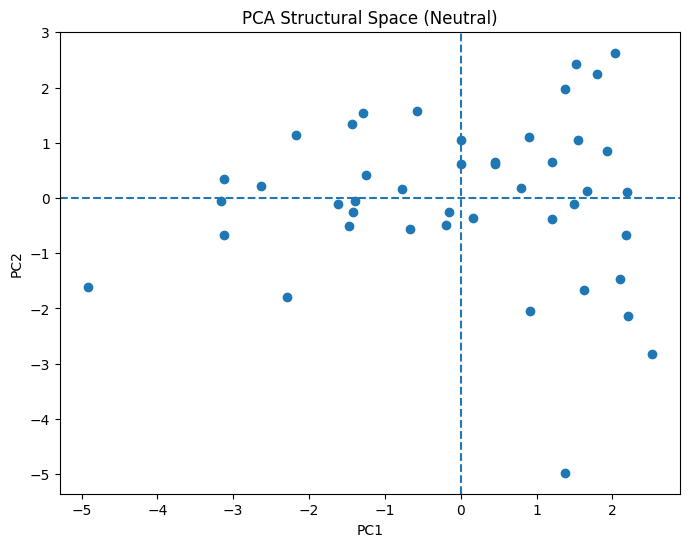

In [37]:
# plot neutral version first to see distribution

plt.figure(figsize=(8,6))
plt.scatter(pc_df["PC1"], pc_df["PC2"])
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Structural Space (Neutral)")
plt.show()

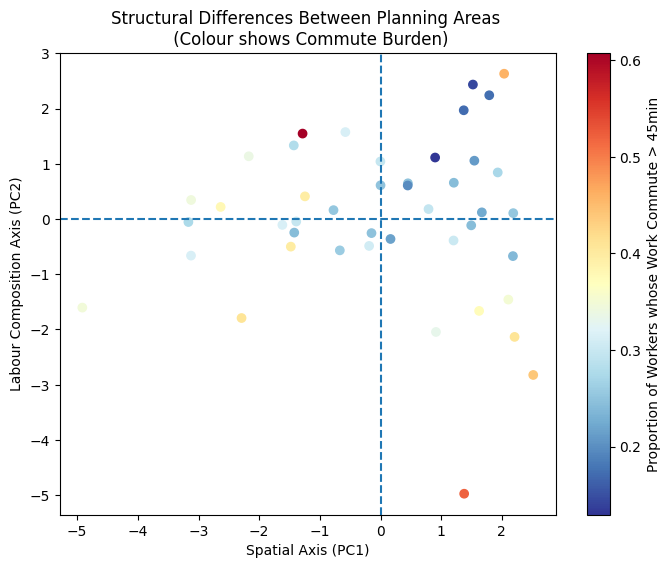

In [38]:
# plot with commute burden as colour

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    pc_df["PC1"],
    pc_df["PC2"],
    c=pc_df["lc_share"],
    cmap="RdYlBu_r"
)
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("Spatial Axis (PC1)") # added this to remind me what they represent to aid interpretation
plt.ylabel("Labour Composition Axis (PC2)") # same as above
plt.title("Structural Differences Between Planning Areas \n (Colour shows Commute Burden)")
plt.colorbar(scatter, label="Proportion of Workers whose Work Commute > 45min")
plt.show()

In [39]:
# using plotly so I can know which planning areas corresponds to which dot when I hover

fig = px.scatter(
    pc_df,
    x="PC1",
    y="PC2",
    color="lc_share",
    color_continuous_scale="RdYlBu_r",
    hover_name="planning_area",  # remove if not available
    labels={
        "PC1": "Spatial Axis (PC1)",
        "PC2": "Labour Composition Axis (PC2)",
        "lc_share": "Proportion of Workers with Commute > 45min"
    },
    title="Structural Differences Between Planning Areas<br>(Colour shows Commute Burden)"
)

# Add dashed reference lines at 0
fig.add_shape(
    type="line",
    x0=pc_df["PC1"].min(),
    x1=pc_df["PC1"].max(),
    y0=0,
    y1=0,
    line=dict(dash="dash")
)

fig.add_shape(
    type="line",
    x0=0,
    x1=0,
    y0=pc_df["PC2"].min(),
    y1=pc_df["PC2"].max(),
    line=dict(dash="dash")
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

In [40]:


midpoint = pc_df["lc_share"].mean()

fig = px.scatter(
    pc_df,
    x="PC1",
    y="PC2",
    color="lc_share",
    color_continuous_scale="RdYlBu_r",
    color_continuous_midpoint=midpoint,
    hover_data={
        "PC1": ":.2f",
        "PC2": ":.2f",
        "lc_share": ":.2f"
    },
    hover_name="planning_area",
    labels={
        "PC1": "Spatial Axis (PC1)",
        "PC2": "Labour Composition Axis (PC2)",
        "lc_share": "Commute Burden"
    },
    title="Structural Differences Between Planning Areas<br>(Colour shows Commute Burden)"
)

# Zero lines
fig.add_hline(y=0, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.update_layout(
    width=800,
    height=600,
    coloraxis_colorbar=dict(
        title="Proportion of Workers<br>>45min Commute"
    )
)

fig.show()

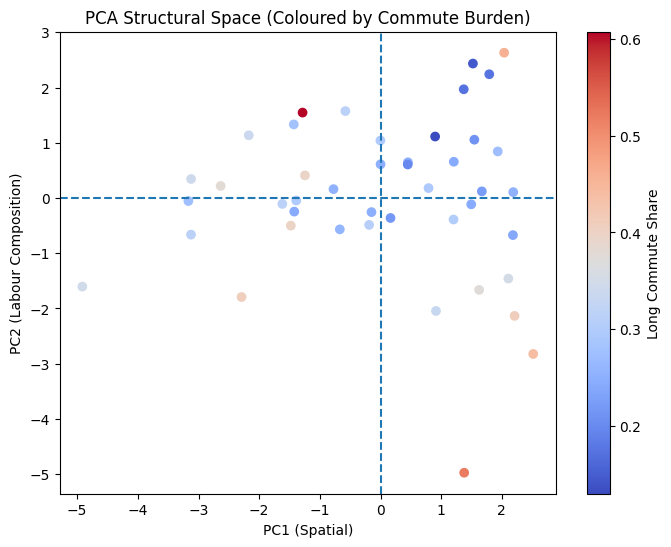

In [41]:
# plot with commute burden as colour

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    pc_df["PC1"],
    pc_df["PC2"],
    c=pc_df["lc_share"],
    cmap="coolwarm" # exploring which version of cmap is more suitable, but I'll use Tableau for the final viz
)
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("PC1 (Spatial)") # added this to remind me what they represent to aid interpretation
plt.ylabel("PC2 (Labour Composition)") # same as above
plt.title("PCA Structural Space (Coloured by Commute Burden)")
plt.colorbar(scatter, label="Long Commute Share")
plt.show()

### Observations:

**Neutral Plot**
- even though the values are roughly spread from -5 to ~2.5 (3) for both PC1 and PC2, the plots are more elogated horizontally
- there are no clear 'gaps' separating possible groups -> suggests this is a gradient system, which urban structure usually is
- PC2 has more variation when PC1 is positive, less variation when PC2 is negative
    - peripheral areas (higher PC1 score) have more labour variation?
    - core areas (lower PC1 score) have less labour variation? (more homogeneous)

**Colored Plot**
- lower lc_share dots clustered in upper-right quadrant (high PC1, high PC2)
- higher lc_share dots appears both:
    - upper-left quadrant (low PC1, high PC2)
    - lower-left quadrant (low PC1, low PC2)
    - lower-right quadrant (high PC1, low PC2)
- commute burden is not monotonic along PC1 (PC2 either high or low)
- labour composition is influencing commute burden (possibly more than distance alone)

**Interesting**
- commute burden seems to vary along both PC1 and PC2
- this variation is not along a simply one-axis (it seems to have two patterns)
    - high PC1, high PC2
    - high PC1, low PC2
    - low PC2, narrower band for PC2 (-2 to 2) (and interwined with low commute)
- thus, the variation for commute burden appears to be a configuration of PC1 and PC2
    - commute burden reflects urban structural configuration
- let's do a correlation matrix for PC1, PC2, lc_share below

In [42]:
pc_df[["PC1", "PC2", "lc_share"]].corr()

,PC1,PC2,lc_share
PC1,1.000000e+00,3.152550e-16,-0.195251
PC2,3.152550e-16,1.000000e+00,-0.435033
lc_share,-1.952506e-01,-4.350334e-01,1.000000


### Notes:
- Good to see that PC1/PC2 is 3.15e-16 (gives me assurance in PCA, that there is no multicollinearity if I use both in regression)
- lc_share/PC1: -0.198
    - weak-to-moderate inverse correlation
    - higher PC1: more peripheral, further from CBD -> lower lc_share (this is unexpected)
    - lower PC1: more central, hub, heavy -> higher lc_share (this is unexpected)
    - this challenges the "peripheral areas tend to have higher commute burden" assumption
- lc_share/PC2: -0.43
    - moderate inverse correlation
    - higher PC2: higher low_share, lower PMET -> lower lc_share 
    - lower PC2: higher PMET -> higher lc_share (hmmm... interesting)
    - possibly suggest that areas with higher PMET concentration are attracting workers from further away?

**Takeaways**
- even though the 6 variables were more strongly shaped by spatial factors, lc_share was not included in PCA, so layering lc_share (commute burden) now is bringing in interesting insights
- commute burden is not as strongly aligned with periphery as it is with labour composition structure
- areas with higher pmet_share are associated with higher lc_share (possible because pmet concentrations are drawing their workers from across Singapore)
- might be even more 'messy' given that Singapore is moving towards decentralisation

<font color = "orange">

## Linear Regression Modelling

</font>

- Model 1: lc_share with PC1
- Model 2: lc_share with PC2
- Model 3: lc_share with PC1 + PC2

In [43]:
# sanity check
print(pc_df[["PC1", "PC2", "lc_share"]].isna().sum())
print(pc_df[["PC1", "PC2", "lc_share"]].describe())

PC1         0
PC2         0
lc_share    0
dtype: int64
                PC1           PC2   lc_share
count  4.400000e+01  4.400000e+01  44.000000
mean   2.018587e-17  5.046468e-18   0.302527
std    1.830878e+00  1.448254e+00   0.096327
min   -4.915533e+00 -4.976553e+00   0.129400
25%   -1.397461e+00 -5.177074e-01   0.242550
50%    3.066967e-01  1.131162e-01   0.295950
75%    1.528841e+00  8.927148e-01   0.348625
max    2.517259e+00  2.631258e+00   0.607800


In [44]:
# Model 1: lc_share ~ PC1
X1 = sm.add_constant(pc_df[["PC1"]])
m1 = sm.OLS(pc_df["lc_share"], X1).fit()

In [45]:
# Model 2: lc_share ~ PC2
X2 = sm.add_constant(pc_df[["PC2"]])
m2 = sm.OLS(pc_df["lc_share"], X2).fit()

In [46]:
# Model 3: lc_share ~ PC1 + PC2
X12 = sm.add_constant(pc_df[["PC1", "PC2"]])
m3 = sm.OLS(pc_df["lc_share"], X12).fit()

In [47]:
# print model summaries
print(m1.summary())
print(m2.summary())
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:               lc_share   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.665
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.204
Time:                        15:15:23   Log-Likelihood:                 41.888
No. Observations:                  44   AIC:                            -79.78
Df Residuals:                      42   BIC:                            -76.21
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3025      0.014     20.993      0.0

In [48]:
results = pd.DataFrame({
    "model": ["PC1", "PC2", "PC1+PC2"],
    "adj_R2": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "R2": [m1.rsquared, m2.rsquared, m3.rsquared],
    "PC1_coef": [m1.params.get("PC1", float("nan")),
                 float("nan"),
                 m3.params.get("PC1", float("nan"))],
    "PC2_coef": [float("nan"),
                 m2.params.get("PC2", float("nan")),
                 m3.params.get("PC2", float("nan"))],
    "PC1_p": [m1.pvalues.get("PC1", float("nan")),
              float("nan"),
              m3.pvalues.get("PC1", float("nan"))],
    "PC2_p": [float("nan"),
              m2.pvalues.get("PC2", float("nan")),
              m3.pvalues.get("PC2", float("nan"))],
})

results

,model,adj_R2,R2,PC1_coef,PC2_coef,PC1_p,PC2_p
0,PC1,0.015221,0.038123,-0.010273,NaN,0.204040,NaN
1,PC2,0.169951,0.189254,NaN,-0.028935,NaN,0.003166
2,PC1+PC2,0.189688,0.227377,-0.010273,-0.028935,0.162494,0.002889


### Observations:

- Overall, the low R2 values was a bit disappointing to see but I suppose that if they were high I'd also feel a bit suspicious
- model 1 confirms that commute burden is not primarily a spatial-driven narrative (based on the correlation matrix earlier on, lc_share and PC1 were -0.198 correlated), but the p-value for PC1 is ~0.2, which is not statistically significant
- model 2 is more promising, and suggests that the labour composition structure is meaningfully associated with commute burden
- model 3 continues to show that the labour axis is more significant (the p-values for PC2 are also <0.05)

**Key Takeaways**
- Commute burden (represented by lc_share) aligns more strongly with labour composition axis (PC2) than spatial axis (PC1)
- Even adding the spatial gradient does not materially improve performance or explanatory power for commute burden
- <font color = "red">This means that commute burden appears to be more associated with occupational structure and job concentration patterns rather than simply (1) distance from CBD and (2) peripheral industrial share</font>
- With an adjusted R2 value of 0.19 (Model 3), it means 19% of variation in commute burden is explained with the structural configuration of PC1 & PC2
- This means the remaining ~80% of commute burden could be due to factors not captured in census data (e.g.residential-job mismatch, transport network topology, industry-specific clustering)
- <font color = "lime">Conclusion: commute burden is moderately associated with labour composition structure, while spatial peripherality plays a limited independent role</font>

In [49]:
# Perform LOOCV (leave one out cross validation)
X = pc_df[["PC1", "PC2"]].values
y = pc_df["lc_share"].values

loo = LeaveOneOut()
lr = LinearRegression()

# Negative MSE scores (sklearn convention), so we flip sign
neg_mse = cross_val_score(lr, X, y, cv=loo, scoring="neg_mean_squared_error")
mse = -neg_mse
rmse = np.sqrt(mse)

print("LOOCV RMSE mean:", rmse.mean())
print("LOOCV RMSE std:", rmse.std())

LOOCV RMSE mean: 0.06433496230123399
LOOCV RMSE std: 0.06528596429477827


### Notes:
- I chose to perform LOOCV because the dataset is small (44 rows)
- I understand that this is a method that partitions the data into subsets for training and testing instead of a single train-test-split, and performs multiple rounds of validation using different portions of the data 
- This is to estimate how well the model will perform on unseen data by repeatedly training and testing on different subsets, thereby providing a reliable measure of model performance (this is a statistical method known as cross validation)

**Interpreting the results**
| LOOCV RMSE mean | LOOCV RMSE std | lc_share std (from above) |
|-----------------|----------------|---------------------------|
|0.065|0.066|0.097|

- Model's typical prediction error = 0.065 / 0.097 = ~67%
- About two-thirds of the natural spread
- The model reduces error by roughly one-third relative to just predicting the mean
- Consistent with R2 of 0.23
- LOOCV RMSE mean roughly equivalent to LOOCV RMSE std -> PC2 association is not purely driven by one single area, model is moderately stable (had RMSE varied more, then it might be due to one or some very influential planning areas)


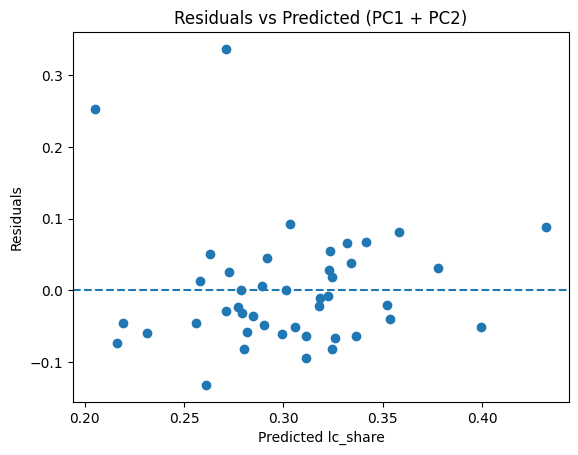

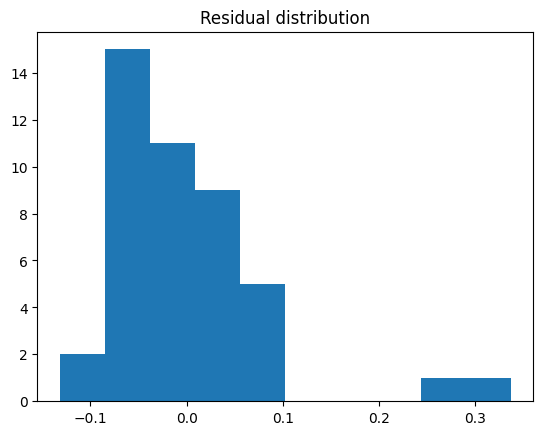

In [50]:
# residual checks
pred = m3.predict(X12)
resid = pc_df["lc_share"] - pred

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted lc_share")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (PC1 + PC2)")
plt.show()

plt.figure()
plt.hist(resid, bins=10)
plt.title("Residual distribution")
plt.show()

### Observations (so far)
- Urban structure can be described or captured into two dominant axes
- Commute burden varies more along labour composition than pure spatial reasons
- The pattern is more continuous like a gradient rather than cleanly separated clusters. This means we can't find distinct "disadvantaged zones"
- This complicates the 'decentralisation is working' narrative for me because instead of saying "let's move jobs to regional centers", we might need to have a more nuanced conversation about "job concentration and labour sorting are shaping commuting patterns". (Urgh, this feels messy)

*Complicating the simplistic decentralisation narrative*
- The narrative goes like this:
    - jobs are too concentrated in the CBD
    - peripheral workers suffer long commutes
    - move jobs to regional centers
    - the result should be a decrease in commute burden
- But the analysis (so far) shows:
    - PC1 (spatial factors: central vs peripheral) is only weakly aligned with commute burden
    - commute burden does not strongly increase with peripherality
    - commute burden aligns more with labour composition (PC2)
    - in simple terms: long commute burden is not primarily a function of how "far" a workplace is from the centre
    - commute burden is shaped by who works where, not just where jobs are located
- The findings implies that commute burden cannot be solved purely by redistributing jobs geographically
    - labour sorting patterns matter
    - job concentration dynamics matter
    - workers *possibly* don't live uniformly around job nodes
- So, if the labour-market structure remains centralised in certain sectors, we can expect that workers may continue to experience long commutes

<font color = "orange">

## Clustering for added interpretation

</font>

(using PC1 and PC2)

<font color = "yellow">

- Primary method: k-Means Clustering
- Secondary method: Hierarchical Clustering

</font>

<font color = "lime">

### k-Means Clustering

</font>

In [51]:
# prepare clustering dataset

X_cluster = pc_df[["PC1", "PC2"]]

In [52]:
sil_scores = {}
inertias = {}

for k in range(2, 8):  # 7 is probably the upper limit for this small data set
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)
    inertias[k] = km.inertia_

In [53]:
# inspect silhouette scores
sil_scores

{2: 0.4069093558330732,
 3: 0.4309033724319058,
 4: 0.39665429595015955,
 5: 0.3988613996498968,
 6: 0.3885405391216137,
 7: 0.4028150884398061}

In [54]:
# inspect inertia for each k
inertias

{2: 127.77291214420723,
 3: 76.62746006197132,
 4: 55.12848132303205,
 5: 43.08953268618612,
 6: 35.32535048531412,
 7: 28.314238238912694}

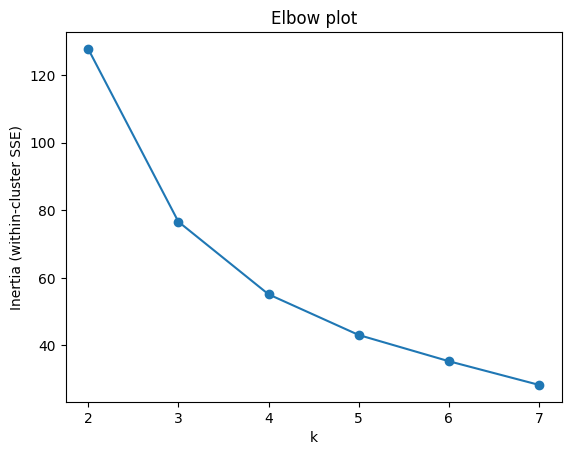

In [55]:
# identify elbow from graph
plt.figure()
plt.plot(list(inertias.keys()), list(inertias.values()), marker='o')
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot")
plt.show()

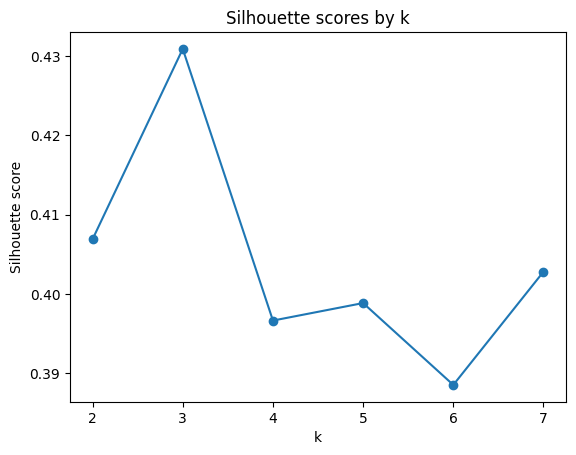

In [56]:
# graph of silhouette scores
plt.figure()
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores by k")
plt.show()

### Observations
- There is no distinct 'elbow' visually (sharp decrease and the gentle gradient), the elbow plot looks like rather smoothened. But k=3 does seem like the best k because it has the highest decrease in inertia, and then a more gradual decrease
- k=3 also has the highest silhouette score. this gives the best balance of:
    - cohesion (points close to their own cluster centroid)
    - separation (clusters are apart from one another)
- k=3 is the most defensible choice
- *based on k-Means clustering k=3, our continuous structural landscape (PC1/PC2) can be partitioned into three broad clusters (but I think it would be naive to say there are three true groups, <font color = "lime">more like there's some meaningful variation in commute burden across the three clusters)</font>*

In [57]:
# use chosen k and label dataset with cluster membership

k = 3 # best k as determined from above
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
pc_df["cluster_k"] = kmeans.fit_predict(X_cluster)

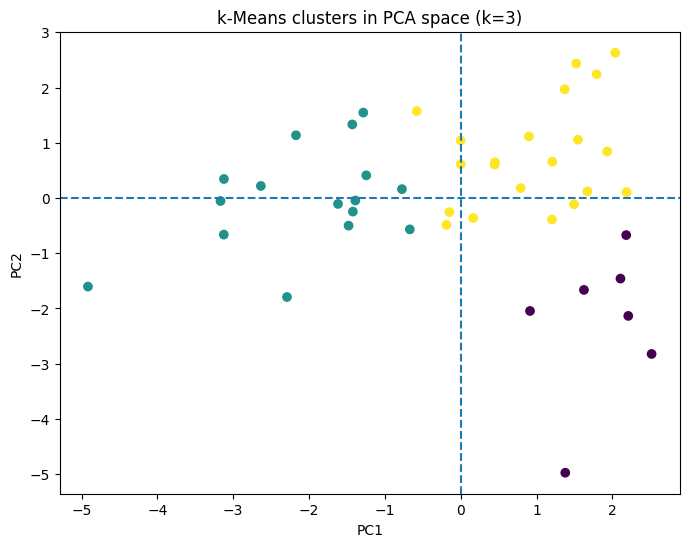

In [58]:
# visualise the clusters in the PCA space
plt.figure(figsize=(8,6))
plt.scatter(pc_df["PC1"], pc_df["PC2"], c=pc_df["cluster_k"])
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("k-Means clusters in PCA space (k=3)")
plt.show()

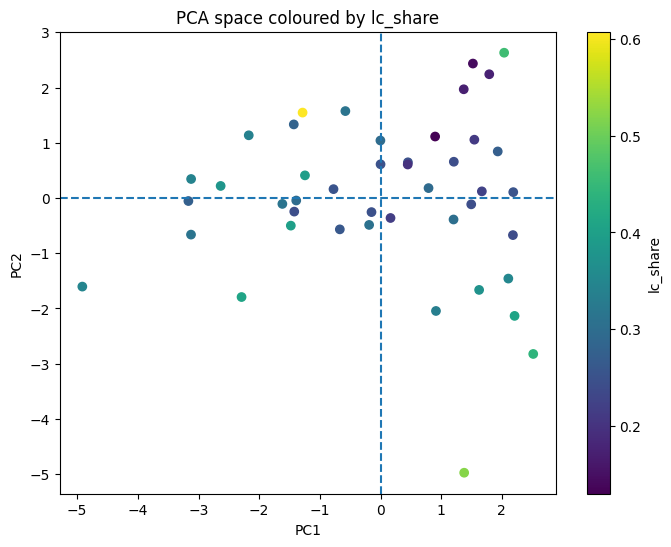

In [59]:
# cluster map (same as above) but with commute burden added 
plt.figure(figsize=(8,6))
sc = plt.scatter(pc_df["PC1"], pc_df["PC2"], c=pc_df["lc_share"])
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA space coloured by lc_share")
plt.colorbar(sc, label="lc_share")
plt.show()

In [60]:
# see what these clusters have in common in tangible terms
summary = pc_df.groupby("cluster_k").agg(
    n=("planning_area", "count"),
    lc_mean=("lc_share", "mean"),
    lc_median=("lc_share", "median"),
    PC1_mean=("PC1", "mean"),
    PC2_mean=("PC2", "mean"),
).sort_values("PC1_mean")

summary

,n,lc_mean,lc_median,PC1_mean,PC2_mean
cluster_k,,,,,
1,16,0.340562,0.3256,-2.046355,-0.027442
2,21,0.247510,0.2475,0.943205,0.772407
0,7,0.380643,0.3726,1.847768,-2.254496


### Observations and Interpretation

**cluster_k 1**
- 16 planning areas
- mean of long commute share = 0.34 (on average, about 34% of the workers in these planning areas experience long commutes (>45min))
- PC1_mean = -2.04 (spatial factor, these are more central or hublike locations)
- PC2_mean = -0.02 (neutral on the labour axis)
    - neither PMET-heavy nor a lot of lower-paying jobs
    - labour composition is relatively balanced
- <font color = "lime"> can be describing the core/hub-dominant cluster
    - possibly central employment nodes that attract workers from across the island</font>

**cluster_k 2**
- 21 planning areas
- mean of long commute share = 0.25 (on average, about 25% of the workers in these planning areas experience long commutes (>45min))
- PC1_mean = 0.94 (spatial factor, these locations are moderately distanced from central)
- PC2_mean = 0.77 (higher PC2 means higher low_share, lower PMET)
- <font color = "lime"> can be describing the transitional / labour-vulnerable cluster
    - areas with more lower-paying jobs do not necessary mean longer commutes (on average)</font>

**cluster_k 3**
- 7 planning areas
- mean of long commute share = 0.38 (on average, about 38% of the workers in these planning areas experience long commutes (>45min))
- PC1_mean = 1.85 (spatial factor, these locations are on the periphery)
- PC2_mean = -2.25 (lower PC2 means high PMET concentration)
- <font color = "lime"> can be describing the peripheral but PMET-heavy cluster
    - likely drawing workers from across the island
    - also aligns with the regression modelling that lower PC2 (more PMET) is associated with higher commute burden</font>

In [61]:
vars_to_describe = ["public_share", "pmet_share", "peripheral_share", "hub_share", "low_share", "distance_km"]

cluster_profile = pc_df[["cluster_k"]].join(X_df[vars_to_describe]).groupby("cluster_k").mean()
cluster_profile

,public_share,pmet_share,peripheral_share,hub_share,low_share,distance_km
cluster_k,,,,,,
0,0.481429,0.612857,0.550000,0.080000,0.204286,18.355304
1,0.691250,0.640625,0.070625,0.293750,0.267500,4.166016
2,0.562381,0.504762,0.172857,0.109524,0.393810,12.998145


<font color = "lime">

### Hierarchical Clustering

</font>

In [62]:
# fit hierarchical using ward linkage
hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
pc_df["cluster_h"] = hier.fit_predict(X_cluster)

In [63]:
# compare hierarchical and k-Means cluster labels
ari = adjusted_rand_score(pc_df["cluster_k"], pc_df["cluster_h"])
ari

# moderately consistent

0.6503798301374828

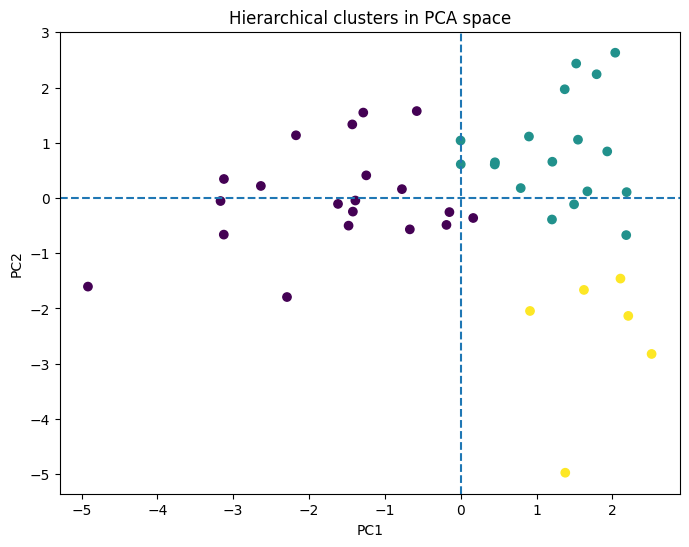

In [64]:
# plot hierarchical clusters
plt.figure(figsize=(8,6))
plt.scatter(pc_df["PC1"], pc_df["PC2"], c=pc_df["cluster_h"])
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical clusters in PCA space")
plt.show()

In [65]:
# out of curiosity, I want to see the dendrogram from the hierarchical clustering
Z = linkage(X_cluster, method='ward')

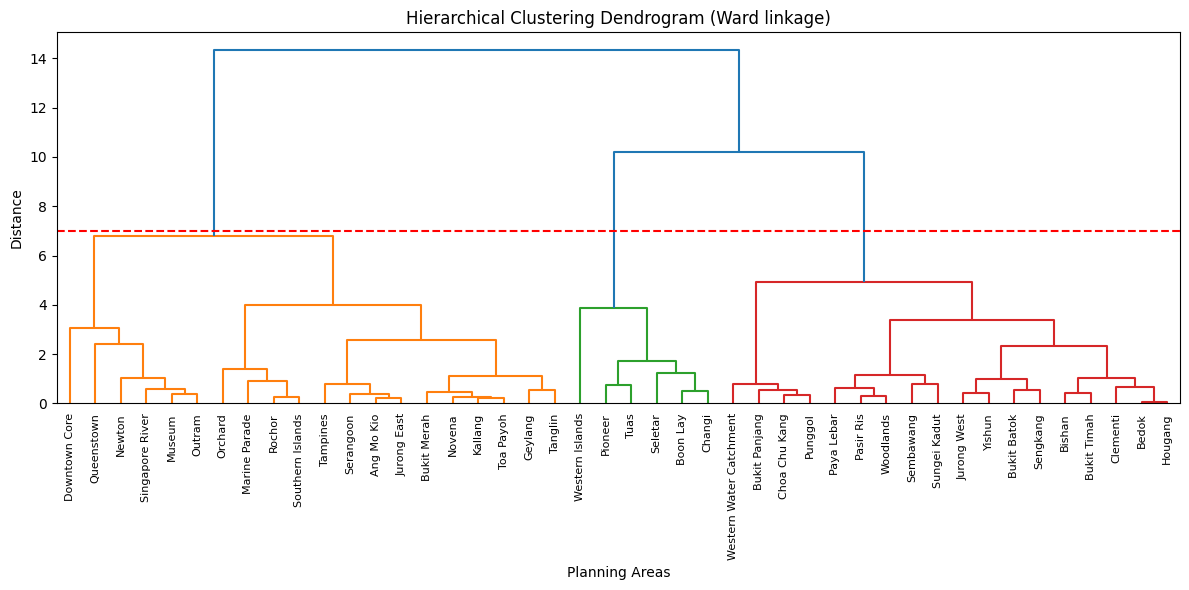

In [66]:
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=pc_df["planning_area"].values,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Planning Areas")
plt.ylabel("Distance")
plt.axhline(y=7, color='r', linestyle='--')
plt.tight_layout()
plt.show()

### Observations and Interpretation

- It is interesting (and somewhat validating) to see that the dendrogram plot also shows three meaningful branches, just like how k=3 was determined from k-Means clustering
    - Left branch (<font color = "orange">in orange</font>): core / central areas
    - Middle branch (<font color = "green">in green</font>): industrial / specialised areas
    - Right branch (<font color = "red">in red</font>): residential / heartland areas
- The merges within each branch are also gradual and not dramatic vertical jumps, that also tells me that the landscape is also on a gradient and not hard partitions (which is what the regression results were showing)

**Reflection**

- I'm glad that I did the dendrogram plot because now it adds another layer of interpretability to the regression (that the urban structure landscape is more of a gradient when it comes to commute burden) and k-Means clustering (that there are three broad 'types' across this gradient)
- But also and lol... seeing Southern Islands in the left branch (core / central areas) is like seeing *a cat amongst a pack of dogs* because I know it has one of the highest lc_share (from the EDA earlier in this jupyter notebook). So it also shows that the structural model accounts for approximately 19% of variation in long commute share, indicating substantial unexplained heterogeneity across planning areas. (will include as a limitation in the report, but probably should adopt a more serious voice instead of my usual irreverant tone)

<img src = "meme.jpg" alt="cat amongst a pack of dogs" width="50%">


In [67]:
pc_df.sort_values("cluster_h")[["planning_area","cluster_h", "cluster_k"]]

,planning_area,cluster_h,cluster_k
0,Ang Mo Kio,0,2
38,Toa Payoh,0,1
37,Tanglin,0,1
36,Tampines,0,1
34,Southern Islands,0,1
33,Singapore River,0,1
32,Serangoon,0,2
28,Rochor,0,1
27,Queenstown,0,1
22,Outram,0,1


### Footnotes:

- I actually started out the modelling using the variables directly (e.g. distance_km, pmet_share, peripheral_share, low_share)
    1. Clustering: k-Means Clustering (Pri) / Hierarchical Cluster (Sec, for robustness)
    2. Linear Regression 
- This was done prior to Project 3: Data Sprint
- After Project 3: Data Sprint, I found it difficult to come back to this analysis because I found it difficult to convey my analysis results in an accessible and defensible way. In fact, I felt like the initial work had been more of going down a technical 'rabbit hole' to just find coefficients of the features to describe commute burden. 
- The R2 values for these initial linear regression models (using the variables directly) did have moderate performance (R2 0.553, adj. R2 0.51)
- In addition, the final linear regression model used the following:
    - "lc_share ~ peripheral_share + pmet_share + low_share + peripheral_share:pmet_share"
    - this was after multiple iterations as I explored different configurations of variables 
    - the resulting R2 value was 0.71 (adj. R2 value was 0.68)
    - but at that point, my cognitive load was overloaded with trying to interpret it cleanly and I recognised that I was simply chasing after better R2 values instead of investigating why *exactly* are these variables influencing commute burden
- Moreover, the variables were exhibiting multicollinearity so that added to my cognitive burden of interpreting my analysis findings (and in some part, actions)
- Thus, I abandoned this line of effort after Project 3 and researched on how to manage multicollinearity in the data set (apart from the obvious choice of dropping some variable)
- The motivation to adopt PCA as the main approach is due to the uncertainty of which variable is "more important". 
- Furthermore, the shortlisted variables represented different dimensions of the urban structure (i.e. spatial positioning, functional role, labour composition) and I risked oversimplifying the structure if I made a judgement call to drop one variable over another
- PCA does not discard variables and instead converts them into independent components (shall not reiterate what the findings are, will address in the formal report, but capturing here for posterity)
- I will include the original jupyter notebook on the initial analysis for reference, but I wanted to capture the rationale for embarking on this trajectory instead here (especially in case future-Michelle gets a bout of amnesia - very likely especially because this week has been particularly stressful on my cognitive load)

<font color = "pink">

## Export to CSV for Visualisation in Tableau

</font>

In [68]:
# for visualising clusters predicted by clustering
pc_df.to_csv("cluster_results.csv", index=False)

In [69]:
# for visualising variables
X_df.to_csv("variables.csv", index=False)

In [70]:
# for visualising time-related variables
time_df.to_csv("time.csv", index=False)